# 4.3.1 L-Shape Domain (Appendix A.3.1)

Reproduces Table 4.6, Figures 4.10-4.14, Table A.12 and Figure A.10 of the thesis: the magnetic
advection-diffusion eigenvalue problem on the L-shaped domain $\Omega_L=(-1,1)^2\setminus([0,1]\times(-1,0])$
in the formulations $A(\mathcal{P}_r)$, $B(\mathcal{N}^{\mathrm{I}}_r)$, $B(\mathcal{N}^{\mathrm{II}}_r)$
on uniform and graded criss-cross meshes. Imports the shared modules `spectral_common.py`,
`pseudospectra_partial_schur.py` and `domain_meshes.py` from this folder. Run top to bottom in a kernel with
Firedrake + SLEPc + MUMPS; figures are written to `./figures`.


## Setup


Matplotlib/LaTeX figure style, imports (shared modules, Dauge reference `DAUGE_LSHAPE`, `lshape_mesh`), `FIGDIR`, and the mesh/convergence panel helpers.


In [1]:
import matplotlib.pyplot as plt

# 1. Document parameters
latex_textwidth_pt = 426.79135 # REPLACE with the number you got from \the\textwidth
inches_per_pt = 1.0 / 72.27
fig_width = latex_textwidth_pt * inches_per_pt
fig_height = fig_width * 0.75 # Standard 4:3 aspect ratio, adjust as needed

base_fontsize = 11 # Or 12, depending on your document class declaration

# 2. Update rcParams globally
plt.rcParams.update({
    "figure.figsize": (fig_width, fig_height),
    
    # Match LaTeX fonts
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    
    # Match font sizes exactly
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize,
    "axes.labelsize": base_fontsize,
    "legend.fontsize": base_fontsize - 1, # Slightly smaller for legend
    "xtick.labelsize": base_fontsize - 2, # Smaller for tick marks
    "ytick.labelsize": base_fontsize - 2,
    
    # Refine line weights for a professional look
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
})

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Optional
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
from IPython.display import display, Markdown

from firedrake import *
from firedrake.pyplot import triplot, quiver

from petsc4py import PETSc

import spectral_common as sc
import pseudospectra_partial_schur as ps
from spectral_common import (solve_pencil, border_gauge, condition_estimates,
                             rates, assign, agreeing_digits, spread, KAPPA_LOG)
import domain_meshes as dm
from domain_meshes import (lshape_mesh, min_cell_volume, sector_hierarchy,
                           sector_maxwell_eigs, corner_rates,
                           DAUGE_LSHAPE, OMEGA_LSHAPE)

# `from firedrake import *` exports a `logging` of its own.
import logging as stdlogging
stdlogging.getLogger("firedrake").setLevel(stdlogging.ERROR)
stdlogging.getLogger("tsfc").setLevel(stdlogging.ERROR)

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

# Everything the LaTeX block above does not set: fonts and sizes come from there.
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "savefig.pad_inches": 0.02})
FIG_SQ = (3.6, 3.4)       # one mesh or eigenfunction panel

#: The pseudospectrum panels are drawn smaller and denser, exactly as in
#: `baseline.ipynb`, so that a grid of them still reads at text width.
PS_RC = {
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02, "ps.fonttype": 42,
}


def show(df, caption=None, **kw):
    """`sc.fmt_table` wired to this notebook's display function."""
    return sc.fmt_table(df, caption=caption,
                        display_fn=lambda c: display(Markdown(f"**{c}**")), **kw)


print(f"PETSc scalars: {PETSc.ScalarType.__name__}")
print("L-shape corner:", {k: round(v, 4) for k, v in
                          corner_rates(OMEGA_LSHAPE).items()})

PETSc scalars: float64
L-shape corner: {'omega': 4.7124, 'alpha': 0.6667, 'h_rate': 1.3333, 'p_rate': 2.6667}


In [3]:
from matplotlib.ticker import LogLocator, NullFormatter

#: The colourblind-safe palette and marker cycle used by every panel here and in
#: `baseline.ipynb`, one entry per tracked eigenvalue.
EIG_COLOURS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]
EIG_MARKS = ["o", "s", "^", "v", "d"]

half_width = fig_width * 0.49          # two panels side by side across the text
half_height = half_width * 1.05
sub_fontsize = base_fontsize - 1

#: The y-label every convergence panel in the dissertation carries.
REL_ERR = r"Rel. Error $|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$"


def save_fig(fig, name):
    r"""Write one panel to `figures/<name>.eps` and `.pdf`.

    Both, because a LaTeX `\includegraphics` given no extension prefers the
    `.pdf`, and a stale one from an earlier style would then be picked silently.
    """
    for ext in ("eps", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}")


def mesh_panel(mesh, name, lw=0.35, **kw):
    """One mesh, no title -- the subcaption carries the label in the document."""
    fig, ax = plt.subplots(figsize=FIG_SQ)
    triplot(mesh, axes=ax, interior_kw={"linewidths": lw}, **kw)
    ax.set_aspect("equal"); ax.axis("off")
    save_fig(fig, name)
    plt.show()


def conv_panel(x, series, *, xlabel, ylabel, title, name, refs=(), logx=True,
               legend_loc="lower right", ncol=2, xticks=None, xticklabels=None,
               numticks=12, minor_x=None):
    r"""One convergence panel in the dissertation's style.

    `series` is a list of `(label, y)`; `refs` a list of `(x, y, kwargs)` for the
    reference slopes, drawn black unless the kwargs say otherwise. The bottom of
    the axis is stretched by a decade so the legend has somewhere to sit.
    """
    minor_x = logx if minor_x is None else minor_x
    fig, ax = plt.subplots(figsize=(half_width, half_height))
    plot = ax.loglog if logx else ax.semilogy

    for j, (label, y) in enumerate(series):
        plot(x, y, marker=EIG_MARKS[j % len(EIG_MARKS)],
             color=EIG_COLOURS[j % len(EIG_COLOURS)], ms=4.0, lw=1.0, label=label)
    for xr, yr, kw in refs:
        plot(xr, yr, **{"color": "k", "lw": 1.1, **kw})

    ax.set_xlabel(xlabel, fontsize=sub_fontsize)
    ax.set_ylabel(ylabel, fontsize=sub_fontsize)
    ax.set_title(title, fontsize=sub_fontsize)
    ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
    ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

    if xticks is not None:
        ax.set_xticks(list(xticks))
        if xticklabels is not None:
            ax.set_xticklabels(list(xticklabels))

    locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=numticks)
    if minor_x:
        ax.xaxis.set_minor_locator(locmin)
        ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_locator(locmin)
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.set_ylim(bottom=ax.get_ylim()[0] * 0.1)
    ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray",
              ncol=ncol, loc=legend_loc, handlelength=1.5, borderpad=0.4)
    plt.tight_layout(pad=0.3)
    save_fig(fig, name)
    plt.show()

The three formulations, `build_pencil`, the shift-and-invert solve (`solve_form`, $\tau = 0.9/R_m$) and the eigenfunction extractor.


In [4]:
def cross2d(a, b):
    r"""Scalar 2D cross product $(a\times b)_z = a_1b_2 - a_2b_1$.

    Antisymmetric, so the ordering is load-bearing: the induction term needs
    $u\times\beta$, the proxy of the contraction $\iota^1_\beta u$.
    """
    return a[0] * b[1] - a[1] * b[0]


def space(form, mesh, r):
    """The mixed (or scalar) space of one formulation at polynomial degree r."""
    if form == "A(P)":
        return FunctionSpace(mesh, "CG", r)
    if form == "B(N1)":
        return FunctionSpace(mesh, "N1curl", r) * FunctionSpace(mesh, "CG", r)
    if form == "B(N2)":
        return FunctionSpace(mesh, "N2curl", r) * FunctionSpace(mesh, "CG", r + 1)
    raise ValueError(f"unknown formulation {form!r}")


def build_pencil(form, mesh, r=1, beta=None, eps=Constant(1.0)):
    r"""Assemble $(A, M)$ for one formulation.  $M$ is singular in every case."""
    if form == "A(P)":
        V = space(form, mesh, r)
        a_, z = TrialFunction(V), TestFunction(V)
        a = eps * inner(grad(a_), grad(z)) * dx
        if beta is not None:
            a += inner(dot(beta, grad(a_)), z) * dx
        K, M = assemble(a).petscmat, assemble(inner(a_, z) * dx).petscmat
        # g_i = \int phi_i : the gauge (A, s) = 0 as a rank-one border.
        g = np.asarray(assemble(TestFunction(V) * dx).dat.data_ro).copy()
        A_b, M_b = border_gauge(K, M, g)
        return A_b, M_b, V

    W = space(form, mesh, r)
    (u, q) = TrialFunctions(W)
    (v, s) = TestFunctions(W)
    a = eps * inner(curl(u), curl(v)) * dx
    if beta is not None:
        a += inner(cross2d(u, beta), curl(v)) * dx
    a += (-inner(grad(q), v) + inner(u, grad(s))) * dx
    # On an H(curl) space a DirichletBC constrains the TANGENTIAL trace.
    bcs = [DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary"),
           DirichletBC(W.sub(1), Constant(0.0), "on_boundary")]
    # weight=0.0 gives the constrained rows a zero mass diagonal, so the
    # boundary modes go to infinity rather than to a spurious lambda = 1.
    return (assemble(a, bcs=bcs).petscmat,
            assemble(inner(u, v) * dx, bcs=bcs, weight=0.0).petscmat, W)


FORMS = ["B(N1)", "B(N2)", "A(P)"]
TEX = {"B(N1)": r"$B(\mathcal{N}^{\mathrm{I}}_r)$",
       "B(N2)": r"$B(\mathcal{N}^{\mathrm{II}}_r)$",
       "A(P)":  r"$A(\mathcal{P}_r)$"}
TEX1 = {f: t.replace("_r", "_1") for f, t in TEX.items()}
TEXP = {f: t.replace("_r", "_p") for f, t in TEX.items()}
TAG = {"B(N1)": "BN1", "B(N2)": "BN2", "A(P)": "AP"}
STYLE = {"B(N1)": "C0", "B(N2)": "C1", "A(P)": "C2"}
MARK = {"B(N1)": "o", "B(N2)": "s", "A(P)": "^"}


def solve_form(form, mesh, r=1, beta=None, Rm=1.0, tau=None, nev=30,
               n_eigs=None, cond=False, **meta):
    r"""Assemble and solve one configuration.  ``tau`` defaults to $0.9\varepsilon$."""
    A, M, W = build_pencil(form, mesh, r, beta=beta, eps=Constant(1.0 / Rm))
    return solve_pencil(A, M, (0.9 / Rm) if tau is None else tau, nev=nev,
                        n_eigs=n_eigs, space=W, cond=cond, form=form, r=r,
                        Rm=Rm, **meta)


def get_mumps_cond1(target_form):
    """The most recent MUMPS COND1 logged for a given formulation."""
    for entry in reversed(KAPPA_LOG):
        if entry.get("form") == target_form:
            return entry.get("MUMPS COND1", float("nan"))
    return float("nan")


def eigenfunction(res, k):
    """The k-th eigenmode: the H(curl) field, or the potential for A(P)."""
    vr, vi = res.A.createVecRight(), res.A.createVecRight()
    res.solver.getEigenvector(int(res.index[k]), vr, vi)
    arr = np.asarray(vr.getArray())
    if res.meta["form"] == "A(P)":
        f = Function(res.space)
        f.dat.data[:] = arr[:res.space.dim()]
        return f
    f = Function(res.space)
    with f.dat.vec_wo as fv:
        fv.setArray(arr[:fv.getLocalSize()])
    return f.subfunctions[0]

Mesh levels $N\in\{4,8,16,32\}$, five tracked eigenvalues, corner exponent $\alpha = 2/3$ of $\Omega_L$.


In [5]:
H_LEVELS = (4, 8, 16, 32)                 # 192, 768, 3072, 12288 cells
EIG_COLS = [rf"$\lambda_{{{j+1}}}$" for j in range(5)]
N_EIGS = 5
CORNER_L = corner_rates(OMEGA_LSHAPE)
ALPHA_L = CORNER_L["alpha"]

Advection fields $\beta_1=(1,1)$, $\beta_2=(x,-y)$, $\beta_4=(-y,x)$, $\beta_7=(\mathrm{sign}\,y,0)$ and the swept list `ADVECTED = [b1, b2, b4]`.


In [6]:
def beta_const(mesh):
    r"""$\beta_1 = (1,1)$: constant, a gradient and solenoidal."""
    return as_vector([Constant(1.0), Constant(1.0)])


def beta_lin(mesh):
    r"""$\beta_2 = (x,-y)$: linear, a gradient and solenoidal."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([x, -y])


def beta_rot(mesh):
    r"""$\beta_4 = (-y,x)$: rigid rotation; solenoidal, not a gradient."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([-y, x])


def beta_sign(mesh):
    r"""$\beta_6 = (\mathrm{sign}\,x,\,0)$: bounded, not Lipschitz.

    A gradient, like $\beta_2$ -- $\mathrm{sign}\,x = \partial_x|x|$ -- so King's
    theorem forces a real spectrum for both and the only thing that separates
    them is regularity.  On $\Omega_L$ the jump line $x = 0$ runs straight
    through the re-entrant corner, which is the worst place to put it.
    """
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(x, Constant(0.0)), 1.0, -1.0), Constant(0.0)])


def _b7(mesh):
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(y, Constant(0,0)), 1.0, -1.0), Constant(0.0)])




@dataclass(frozen=True)
class Field:
    key: str
    tex: str
    regularity: str
    note: str
    _build: Optional[Callable]

    def __call__(self, mesh):
        return None if self._build is None else self._build(mesh)


FIELDS = {
    "b0": Field("b0", r"$0$", "--", "--", None),
    "b1": Field("b1", r"$\beta_1$", r"$W^{1,\infty}$", "constant", beta_const),
    "b2": Field("b2", r"$\beta_2$", r"$W^{1,\infty}$", "linear", beta_lin),
    "b4": Field("b4", r"$\beta_4$", r"$W^{1,\infty}$", "rotation", beta_rot),
    "b6": Field("b6", r"$\beta_6$",
                r"$L^\infty\setminus W^{1,\infty}$", "jump through the corner",
                beta_sign),
    "b7": Field("b7", r"$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$",
                r"$L^\infty\setminus W^{1,\infty}$", 'v', _b7),
}

#: The fields swept below.  Every advected table and figure loops over this list,
#: so the sweep is widened or narrowed here and nowhere else.
ADVECTED = ["b1", "b2",'b4']

## Table 4.6: L-shape eigenvalues without advection


First five eigenvalues of the three formulations against Dauge's reference, with DoF and MUMPS `COND1`. $\beta=0$, $R_m=1$, uniform criss-cross $N=32$ (12288 cells), $p=2$, $\tau=0.9$, `nev=30` / 5 eigenvalues.


In [7]:
mesh_fine = lshape_mesh(H_LEVELS[-1])
rows = {}
res_fine = {}

for f in FORMS:
    res = solve_form(f, mesh_fine, 2, n_eigs=N_EIGS, cond=True, beta_key="b0")
    res_fine[f] = res
    got = assign(DAUGE_LSHAPE, res.values)
    rows[(f, "DoF")] = res.size
    rows[(f, r"$\lambda_h$")] = got.real
    rows[(f, "rel. err.")] = np.abs(got - DAUGE_LSHAPE) / DAUGE_LSHAPE
frame = pd.DataFrame(
    {"Dauge $\\lambda^{(i)}$": DAUGE_LSHAPE,
     **{f"{f} $\\lambda_h$": rows[(f, r"$\lambda_h$")] for f in FORMS},
     **{f"{f} err": rows[(f, "rel. err.")] for f in FORMS}},
    index=[rf"$\lambda_{{{j+1}}}$" for j in range(N_EIGS)])

show(frame, default="{:.6f}", rules=[("err", "{:.2e}"), ("Dauge", "{:.9f}")],
     caption=rf"First five eigenvalues on $\Omega_L$ at "
             rf"$N = {mesh_fine.num_cells()}$ cells, $r = 1$, $\beta = 0$. "
             rf"DoF: " + ", ".join(f"{f} {res_fine[f].size}" for f in FORMS)
             + r". MUMPS COND1: "
             + ", ".join(f"{get_mumps_cond1(f):.1e}" for f in FORMS))

**First five eigenvalues on $\Omega_L$ at $N = 12288$ cells, $r = 1$, $\beta = 0$. DoF: B(N1) 86529, B(N2) 148225, A(P) 24834. MUMPS COND1: 3.1e+05, 2.4e+05, 1.9e+02**

,Dauge $\lambda^{(i)}$,B(N1) $\lambda_h$,B(N2) $\lambda_h$,A(P) $\lambda_h$,B(N1) err,B(N2) err,A(P) err
$\lambda_{1}$,1.475621824,1.475252,1.475474,1.475992,2.51e-04,1.00e-04,2.51e-04
$\lambda_{2}$,3.534031367,3.534030,3.534031,3.534032,2.53e-07,2.96e-08,2.61e-07
$\lambda_{3}$,9.869604401,9.869605,9.869605,9.869605,1.49e-08,2.42e-08,5.16e-08
$\lambda_{4}$,9.869604401,9.869605,9.869605,9.869605,1.49e-08,2.42e-08,5.16e-08
$\lambda_{5}$,11.389479398,11.389478,11.389480,11.389481,1.03e-07,1.47e-08,1.66e-07


## Figure 4.10: L-shape eigenvalue errors under h- and p-refinement (β = 0)


(a) $h$-refinement at $p=1$, $N\in\{4,8,16,32\}$ (`h_study`, 10 tracked eigenvalues, `nev=70`); (b) $p$-refinement at $N=8$, $p=1,\dots,4$ (`p_study`, `nev=40`). $\beta=0$, $R_m=1$, $\tau=0.9$, reference from Dauge. One panel per formulation: `domreg_h_b0_{AP,BN1,BN2}.eps`, `domreg_p_b0_{AP,BN1,BN2}.eps`; the thesis shows the `AP` panels.


In [8]:
def h_study(form, levels=H_LEVELS, r=1, beta_fn=None, Rm=1.0, reference=None,
            gamma=1.0, n_eigs=N_EIGS, cond=True):
    """Errors for referenced modes, and raw values for the unreferenced ones."""
    ref = DAUGE_LSHAPE if reference is None else reference
    
    err_cols = [rf"$\lambda_{{{j+1}}}$" for j in range(len(ref))]
    val_cols = [rf"$\lambda_{{{j+1}}}$ (val)" for j in range(len(ref), n_eigs)]
    
    rows = []
    for n in levels:
        mesh = lshape_mesh(n, gamma=gamma)
        beta = None if beta_fn is None else beta_fn(mesh)
        res = solve_form(form, mesh, r, beta=beta, Rm=Rm, nev=6 * n_eigs + 10,
                         cond=cond)
        
        got = assign(ref, res.values)
        row_data = dict(n=n, h=1.0 / n, dof=res.size)
        
        for j in range(len(ref)):
            row_data[err_cols[j]] = abs(got[j] - ref[j]) / abs(ref[j])
            
        remaining = list(res.values)
        for v in got:
            idx = (np.abs(np.array(remaining) - v)).argmin()
            remaining.pop(idx)
            
        remaining = np.sort(remaining)
        
        for j in range(len(ref), n_eigs):
            if (j - len(ref)) < len(remaining):
                row_data[val_cols[j - len(ref)]] = remaining[j - len(ref)]
            else:
                row_data[val_cols[j - len(ref)]] = np.nan
                
        # Pull the condition number from the global log instead of the res object
        row_data["MUMPS cond"] = get_mumps_cond1(form)
        rows.append(row_data)
        
    return pd.DataFrame(rows).set_index("n")

def rate_frame(df, err_cols):
    out = pd.DataFrame(index=df.index)
    out["h"] = df["h"]
    
    for c in err_cols:
        if c in df.columns:
            out[c] = df[c]
            out[f"rate {c}"] = rates(df["h"], df[c])
            
    val_cols = [c for c in df.columns if "(val)" in c]
    for c in val_cols:
        out[c] = df[c]
        
    out["MUMPS cond"] = df["MUMPS cond"]
    return out





In [9]:

# Execution
h_b0 = {f: h_study(f, n_eigs=10, Rm=1) for f in FORMS}
EIG_COLS = [rf"$\lambda_{{{j+1}}}$" for j in range(len(DAUGE_LSHAPE))]

for f in FORMS:
    display(show(rate_frame(h_b0[f], EIG_COLS), default="{:.3e}",
                 rules=[("rate", "{:.2f}"), 
                        ("h", "{:.5f}"), 
                        ("dof", "{:.0f}"),
                        ("(val)", "{:.5f}"),
                        ("MUMPS cond", "{:.2e}")],
                 caption=rf"$h$-refinement on $\Omega_L$, **{f}**, $\beta=0$, "
                         rf"$r=1$ (theory: $\lambda_1 \to {CORNER_L['h_rate']:.2f}$, "
                         rf"the rest $\to 2$)"))

**$h$-refinement on $\Omega_L$, **B(N1)**, $\beta=0$, $r=1$ (theory: $\lambda_1 \to 1.33$, the rest $\to 2$)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\lambda_{6}$ (val),$\lambda_{7}$ (val),$\lambda_{8}$ (val),$\lambda_{9}$ (val),$\lambda_{10}$ (val),MUMPS cond
n,,,,,,,,,,,,,,,,,
4,0.25000,2.152e-02,--,2.544e-04,--,4.164e-03,--,4.164e-03,--,1.827e-03,--,12.40881,19.39847,21.24286,23.49578,27.70337,8.18e+02
8,0.12500,8.791e-03,1.29,9.994e-06,4.67,1.064e-03,1.97,1.064e-03,1.97,4.628e-04,1.98,12.51569,19.65450,21.34940,23.38318,28.25325,3.19e+03
16,0.06250,3.550e-03,1.31,6.143e-06,0.70,2.673e-04,1.99,2.673e-04,1.99,1.184e-04,1.97,12.55181,19.71806,21.39148,23.35395,28.41498,1.22e+04
32,0.03125,1.424e-03,1.32,2.914e-06,1.08,6.690e-05,2.00,6.690e-05,2.00,3.015e-05,1.97,12.56469,19.73392,21.41048,23.34673,28.46531,4.75e+04


**$h$-refinement on $\Omega_L$, **B(N2)**, $\beta=0$, $r=1$ (theory: $\lambda_1 \to 1.33$, the rest $\to 2$)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\lambda_{6}$ (val),$\lambda_{7}$ (val),$\lambda_{8}$ (val),$\lambda_{9}$ (val),$\lambda_{10}$ (val),MUMPS cond
n,,,,,,,,,,,,,,,,,
4,0.25000,1.519e-03,--,6.070e-03,--,1.707e-02,--,1.707e-02,--,1.970e-02,--,12.82413,20.41625,22.15531,24.28017,29.82745,8.52e+02
8,0.12500,9.570e-04,0.67,1.524e-03,1.99,4.280e-03,2.00,4.280e-03,2.00,4.937e-03,2.00,12.63308,19.90843,21.60446,23.58012,28.82197,3.10e+03
16,0.06250,4.719e-04,1.02,3.818e-04,2.00,1.071e-03,2.00,1.071e-03,2.00,1.235e-03,2.00,12.58649,19.78149,21.46731,23.40342,28.57101,1.20e+04
32,0.03125,2.106e-04,1.16,9.561e-05,2.00,2.677e-04,2.00,2.677e-04,2.00,3.088e-04,2.00,12.57548,19.74978,21.43436,23.35914,28.50976,4.73e+04


**$h$-refinement on $\Omega_L$, **A(P)**, $\beta=0$, $r=1$ (theory: $\lambda_1 \to 1.33$, the rest $\to 2$)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\lambda_{6}$ (val),$\lambda_{7}$ (val),$\lambda_{8}$ (val),$\lambda_{9}$ (val),$\lambda_{10}$ (val),MUMPS cond
n,,,,,,,,,,,,,,,,,
4,0.25000,2.977e-02,--,9.799e-03,--,3.457e-02,--,3.457e-02,--,3.269e-02,--,13.12379,20.60792,23.29510,25.15152,30.87804,6.36e+00
8,0.12500,1.077e-02,1.47,2.505e-03,1.97,8.587e-03,2.01,8.587e-03,2.01,8.133e-03,2.01,12.72457,19.95208,21.91641,23.79360,29.10588,2.13e+01
16,0.06250,4.034e-03,1.42,6.350e-04,1.98,2.143e-03,2.00,2.143e-03,2.00,2.033e-03,2.00,12.61674,19.79215,21.56160,23.45659,28.65933,3.90e+01
32,0.03125,1.544e-03,1.39,1.601e-04,1.99,5.355e-04,2.00,5.355e-04,2.00,5.085e-04,2.00,12.58602,19.75243,21.46486,23.37245,28.53936,7.46e+01


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


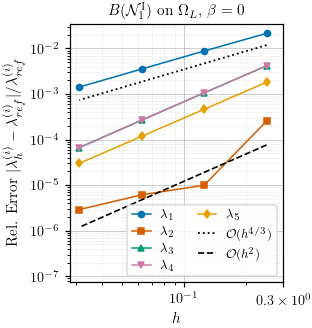

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


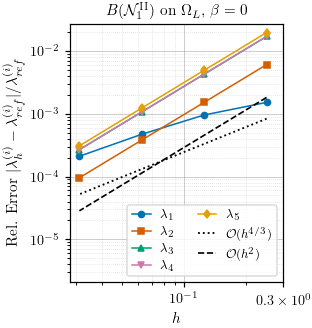

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


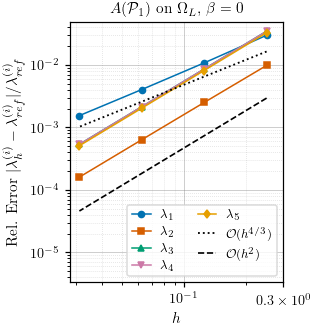

In [10]:
for f in FORMS:
    df = h_b0[f]
    h = df["h"].to_numpy()
    e0, e1 = df[EIG_COLS[0]].to_numpy(), df[EIG_COLS[1]].to_numpy()
    conv_panel(
        h, [(rf"$\lambda_{{{j+1}}}$", df[EIG_COLS[j]].to_numpy())
            for j in range(N_EIGS)],
        refs=[(h, 0.55 * e0[0] * (h / h[0]) ** CORNER_L["h_rate"],
               dict(ls=":", lw=1.2, label=r"$\mathcal{O}(h^{4/3})$")),
              (h, 0.30 * e1[0] * (h / h[0]) ** 2,
               dict(ls="--", lw=1.1, label=r"$\mathcal{O}(h^{2})$"))],
        xlabel=r"$h$", ylabel=REL_ERR,
        title=rf"{TEX1[f]} on $\Omega_L$, $\beta = 0$",
        xticks=[0.1, 0.3], xticklabels=[r"$10^{-1}$", r"$0.3 \times 10^{0}$"],
        name=f"domreg_h_b0_{TAG[f]}")

In [11]:
P_LEVELS = (1, 2, 3, 4)
P_N = 8


def p_study(form, N=P_N, degrees=P_LEVELS, beta_fn=None, Rm=1.0,
            reference=None, gamma=1.0, cond=True):
    ref = DAUGE_LSHAPE if reference is None else reference
    cols = [rf"$\lambda_{{{j+1}}}$" for j in range(len(ref))]
    mesh = lshape_mesh(N, gamma=gamma)
    beta = None if beta_fn is None else beta_fn(mesh)
    rows = []
    for r in degrees:
        res = solve_form(form, mesh, r, beta=beta, Rm=Rm,
                         nev=6 * len(ref) + 10, cond=cond)
        got = assign(ref, res.values)
        rows.append(dict(r=r, dof=res.size,
                         **{cols[j]: abs(got[j] - ref[j]) / abs(ref[j])
                            for j in range(len(ref))},
                         **{r"$\kappa_1$": res.kappa1}))
    return pd.DataFrame(rows).set_index("r")

In [12]:

p_b0 = {f: p_study(f) for f in FORMS}
rows = {}
for f in FORMS:
    df = p_b0[f]
    pp = np.asarray(df.index, float)
    for j, c in enumerate(EIG_COLS):
        q = -np.polyfit(np.log(pp), np.log(df[c].to_numpy()), 1)[0]
        rows.setdefault(f, {})[c] = q
frame = pd.DataFrame(rows).T
frame[r"theory $4\alpha$"] = CORNER_L["p_rate"]
show(frame, default="{:.2f}",
     caption=rf"$p$-refinement on $\Omega_L$, $\beta=0$: fitted algebraic exponent "
             rf"$q$ in $\mathcal{{O}}(p^{{-q}})$ at $N = {12*P_N**2}$ cells. "
             rf"Only $\lambda_1$ is meant to match $4\alpha$; the rest are not "
             rf"algebraic at all.")
for f in FORMS:
    display(show(p_b0[f], default="{:.3e}",
                 rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$p$-refinement, **{f}**, $\beta=0$, "
                         rf"$N = {12*P_N**2}$ cells"))

**$p$-refinement on $\Omega_L$, $\beta=0$: fitted algebraic exponent $q$ in $\mathcal{O}(p^{-q})$ at $N = 768$ cells. Only $\lambda_1$ is meant to match $4\alpha$; the rest are not algebraic at all.**

**$p$-refinement, **B(N1)**, $\beta=0$, $N = 768$ cells**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,1601,8.791e-03,9.994e-06,1.064e-03,1.064e-03,4.628e-04,9.27e+04
2,5505,1.590e-03,9.914e-06,3.788e-06,3.788e-06,1.943e-06,1.84e+06
3,11713,6.347e-04,1.303e-06,3.632e-09,3.632e-09,5.861e-07,2.52e+07
4,20225,3.236e-04,3.238e-07,1.867e-12,1.922e-12,1.449e-07,1.18e+08


**$p$-refinement, **B(N2)**, $\beta=0$, $N = 768$ cells**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,3969,9.570e-04,1.524e-03,4.280e-03,4.280e-03,4.937e-03,2.63e+05
2,9409,6.341e-04,5.940e-07,6.164e-06,6.164e-06,6.821e-06,2.75e+06
3,17153,3.236e-04,3.230e-07,4.747e-09,4.747e-09,1.383e-07,2.40e+07
4,27201,1.892e-04,1.085e-07,2.235e-12,2.263e-12,4.838e-08,1.25e+08


**$p$-refinement, **A(P)**, $\beta=0$, $N = 768$ cells**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,418,1.077e-02,2.505e-03,8.587e-03,8.587e-03,8.133e-03,2.59e+03
2,1602,1.589e-03,1.190e-05,1.311e-05,1.311e-05,1.808e-05,1.33e+04
3,3554,6.349e-04,1.306e-06,8.379e-09,8.379e-09,5.761e-07,4.98e+04
4,6274,3.237e-04,3.242e-07,4.057e-12,4.063e-12,1.430e-07,1.16e+05


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


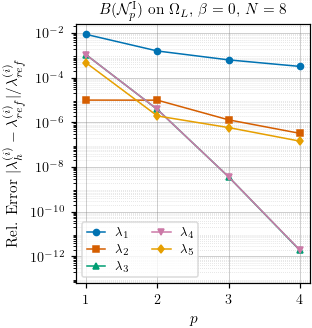

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


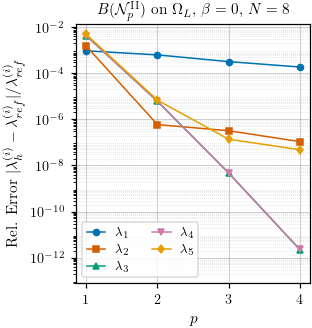

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


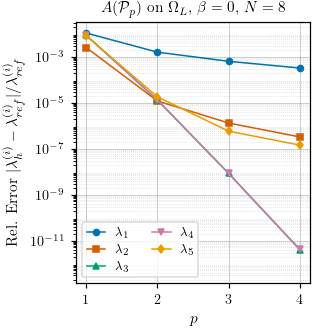

In [13]:
# Figure 4.12(b) and its companions: p-refinement on a fixed mesh.  The corner
# mode is algebraic in p, the rest are exponential.
for f in FORMS:
    df = p_b0[f]
    pp = np.asarray(df.index, float)
    conv_panel(
        pp, [(rf"$\lambda_{{{j+1}}}$", df[EIG_COLS[j]].to_numpy())
             for j in range(N_EIGS)],
        xlabel=r"$p$", ylabel=REL_ERR,
        title=rf"{TEXP[f]} on $\Omega_L$, $\beta = 0$, $N = {P_N}$",
        logx=False, xticks=P_LEVELS, numticks=40, legend_loc="lower left",
        name=f"domreg_p_b0_{TAG[f]}")

## Figure 4.11: Example L-shape eigenfunctions from B(N1^I)


Quiver plots of two $B(\mathcal{N}^{\mathrm{I}}_1)$ eigenmodes on $\Omega_L$: $\beta=0$, $R_m=1$, $N=8$, $p=1$, `nev=30` / 6 eigenvalues. Files `domreg_mode_corner.eps` (mode index 0) and `domreg_mode_smooth.eps` (mode index 3).


In [14]:
res_mode = solve_form("B(N1)", lshape_mesh(8), 1, nev=30, n_eigs=6)
u_corner = eigenfunction(res_mode, 0)
u_smooth = eigenfunction(res_mode, 3)
print(f"lambda_1 = {res_mode.values[0].real:.6f},  "
      f"lambda_4 = {res_mode.values[1].real:.6f}")

lambda_1 = 1.462650,  lambda_4 = 3.534067


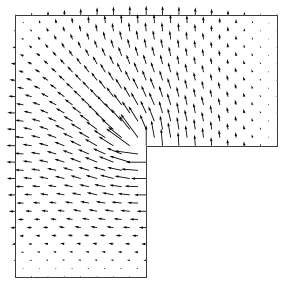

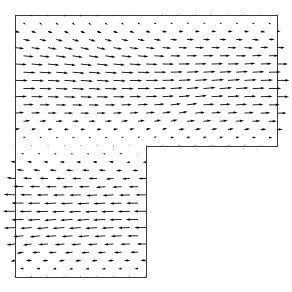

In [15]:
# Figure 4.11: the singular fundamental and a smooth mode, on the same mesh.
from matplotlib.colors import ListedColormap
black_cmap = ListedColormap(["black"])

for u, name in ((u_corner, "domreg_mode_corner"), (u_smooth, "domreg_mode_smooth")):
    fig, ax = plt.subplots(figsize=FIG_SQ)
    triplot(u.function_space().mesh(), axes=ax, interior_kw={"linewidth": 0},
            boundary_kw={"color": "black", "linewidth": 0.5})
    quiver(u, axes=ax, cmap=black_cmap)
    ax.set_aspect("equal"); ax.axis("off")
    save_fig(fig, name)
    plt.show()

## Figure 4.12: Mesh grading and the convergence of the singular eigenvalue λ1


Grading $x\mapsto\mathrm{sign}(x)|x|^{1/\gamma}$ (and in $y$) for $\gamma\in\{1,0.8,2/3,1/2\}$. (a) the graded mesh at $\gamma=0.5$, $N=8$: `domreg_graded_mesh_g05.eps` (parameter re-run, see Notes); (b) $\lambda_1$ error of $A(\mathcal{P}_1)$ under $h$-refinement per $\gamma$: $\beta=0$, $R_m=1$, $N\in\{4,8,16,32\}$, $p=1$, $\tau=0.9$, `nev=40`; `domreg_graded_h_AP.eps`. The rate table covers all three formulations.


In [16]:
GAMMAS = (1.0, 0.8, 2.0 / 3.0, 0.5)
GAMMA_TEX = {1.0: r"$\gamma=1$ (uniform)", 0.8: r"$\gamma=0.8$",
             2.0 / 3.0: r"$\gamma=2/3$", 0.5: r"$\gamma=1/2$"}
frame = pd.DataFrame(
    [dict(gamma=g, **{"cells": 12 * 16 ** 2,
                      "min cell volume": min_cell_volume(lshape_mesh(16, gamma=g)),
                      "$h$ away from the corner": 1.0 / 16,
                      "$h$ at the corner": (1.0 / 16) ** (1.0 / g),
                      r"predicted rate $2\min(1,\alpha/\gamma)$":
                          2.0 * min(1.0, ALPHA_L / g)})
     for g in GAMMAS]).set_index("gamma")
show(frame, default="{:.4f}", rules=[("cells", "{:.0f}"),
                                     ("min cell volume", "{:.2e}"),
                                     ("at the corner", "{:.2e}")],
     caption=r"The grading sweep at $n=16$. A positive minimum cell volume is the "
             r"check that the map has not inverted an element.")

**The grading sweep at $n=16$. A positive minimum cell volume is the check that the map has not inverted an element.**

,cells,min cell volume,$h$ away from the corner,$h$ at the corner,"predicted rate $2\min(1,\alpha/\gamma)$"
gamma,,,,,
1.000000,3072,9.77e-04,0.0625,6.25e-02,1.3333
0.800000,3072,2.05e-04,0.0625,3.12e-02,1.6667
0.666667,3072,4.32e-05,0.0625,1.56e-02,2.0000
0.500000,3072,1.91e-06,0.0625,3.91e-03,2.0000


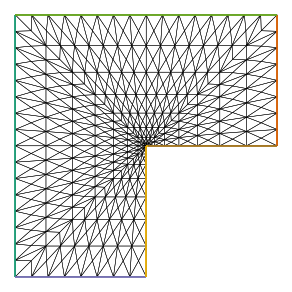

In [17]:
# Figure 4.13(a): the graded mesh itself.
mesh_panel(lshape_mesh(8, gamma=0.5), "domreg_graded_mesh_g05", lw=0.3)

In [18]:
GRADE_LEVELS = (4, 8, 16, 32)
h_graded = {(f, g): h_study(f, GRADE_LEVELS, gamma=g, cond=(f == "A(P)"))
            for f in FORMS for g in GAMMAS}
rows = {}
for f in FORMS:
    for g in GAMMAS:
        df = h_graded[(f, g)]
        hh = df["h"].to_numpy()
        rows[(f, GAMMA_TEX[g])] = {
            **{c: rates(hh, df[c].to_numpy())[-1] for c in EIG_COLS},
            r"predicted $\lambda_1$": 2.0 * min(1.0, ALPHA_L / g),
            r"$\lambda_1$ error, finest": df[EIG_COLS[0]].to_numpy()[-1]}
frame = pd.DataFrame(rows).T
frame.index = pd.MultiIndex.from_tuples(frame.index, names=["form", "grading"])
show(frame, default="{:.2f}", rules=[("error", "{:.2e}")],
     caption=r"Observed rate on the finest pair against the grading prediction "
             r"$2\min(1,\alpha/\gamma)$, $\beta=0$, $r=1$. The rate is recovered "
             r"in every formulation at once, which is what says the cap was the "
             r"mesh's.")

**Observed rate on the finest pair against the grading prediction $2\min(1,\alpha/\gamma)$, $\beta=0$, $r=1$. The rate is recovered in every formulation at once, which is what says the cap was the mesh's.**

$\lambda_{1}$ $\lambda_{2}$ $\lambda_{3}$  \
form  grading                                                          
B(N1) $\gamma=1$ (uniform)          1.32          1.08          2.00   
      $\gamma=0.8$                  1.61          2.00          2.00   
      $\gamma=2/3$                  1.83          2.05          1.99   
      $\gamma=1/2$                  1.98          2.00          2.00   
B(N2) $\gamma=1$ (uniform)          1.16          2.00          2.00   
      $\gamma=0.8$                  1.34          2.00          2.00   
      $\gamma=2/3$                  2.00          2.00          2.00   
      $\gamma=1/2$                  1.92          2.00          1.99   
A(P)  $\gamma=1$ (uniform)          1.39          1.99          2.00   
      $\gamma=0.8$                  1.69          2.00          2.00   
      $\gamma=2/3$                  1.89          2.00          2.00   
      $\gamma=1/2$                  2.00          2.00          2.01   

                           $\lambda_{4}$ $\lambda_{5}$ predicted $\lambda_1$  \
form  grading                                                                  
B(N1) $\gamma=1$ (uniform)          2.00          1.97                  1.33   
      $\gamma=0.8$                  2.00          2.01                  1.67   
      $\gamma=2/3$                  2.00          2.01                  2.00   
      $\gamma=1/2$                  1.99          2.00                  2.00   
B(N2) $\gamma=1$ (uniform)          2.00          2.00                  1.33   
      $\gamma=0.8$                  2.00          2.00                  1.67   
      $\gamma=2/3$                  2.00          2.00                  2.00   
      $\gamma=1/2$                  2.00          2.00                  2.00   
A(P)  $\gamma=1$ (uniform)          2.00          2.00                  1.33   
      $\gamma=0.8$                  2.00          2.00                  1.67   
      $\gamma=2/3$                  2.00          2.00                  2.00   
      $\gamma=1/2$                  1.99          2.00                  2.00   

                           $\lambda_1$ error, finest  
form  grading                                         
B(N1) $\gamma=1$ (uniform)                  1.42e-03  
      $\gamma=0.8$                          6.18e-04  
      $\gamma=2/3$                          3.56e-04  
      $\gamma=1/2$                          2.79e-04  
B(N2) $\gamma=1$ (uniform)                  2.11e-04  
      $\gamma=0.8$                          4.26e-05  
      $\gamma=2/3$                          8.29e-06  
      $\gamma=1/2$                          3.31e-05  
A(P)  $\gamma=1$ (uniform)                  1.54e-03  
      $\gamma=0.8$                          7.62e-04  
      $\gamma=2/3$                          5.35e-04  
      $\gamma=1/2$                          5.42e-04

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


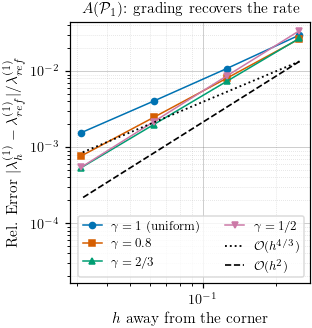

In [19]:
# Figure 4.13(b): grading recovers the rate.  One curve per gamma, both reference
# slopes drawn from the uniform run.
hh_ref = h_graded[("A(P)", 1.0)]["h"].to_numpy()
e0 = h_graded[("A(P)", 1.0)][EIG_COLS[0]].to_numpy()[0]

conv_panel(
    hh_ref,
    [(GAMMA_TEX[g], h_graded[("A(P)", g)][EIG_COLS[0]].to_numpy()) for g in GAMMAS],
    refs=[(hh_ref, 0.45 * e0 * (hh_ref / hh_ref[0]) ** CORNER_L["h_rate"],
           dict(ls=":", lw=1.2, label=r"$\mathcal{O}(h^{4/3})$")),
          (hh_ref, 0.45 * e0 * (hh_ref / hh_ref[0]) ** 2,
           dict(ls="--", lw=1.1, label=r"$\mathcal{O}(h^{2})$"))],
    xlabel=r"$h$ away from the corner",
    ylabel=r"Rel. Error $|\lambda_h^{(1)} - \lambda_{ref}^{(1)}| / \lambda_{ref}^{(1)}$",
    title=r"$A(\mathcal{P}_1)$: grading recovers the rate",
    name="domreg_graded_h_AP")

## Figure 4.13: L-shape h-refinement errors under β1 and β4


Cross-validated reference for $\beta_1,\beta_2,\beta_4$: mean of the three formulations at $N=32$, $p=2$, $\gamma=1$, $R_m=1$, $\tau=0.9$, 100 eigenvalues (full table; the thesis view is Table A.12 below). Then $h$-refinement at $p=1$, $N\in\{4,8,16,32\}$, $\gamma=1$, $R_m=1$, $\tau=0.9$, `nev=40`, with the spread as reference floor. Panels `domreg_h_{b1,b2,b4}_{AP,BN1,BN2}.eps`; the thesis shows `domreg_h_b1_AP.eps` and `domreg_h_b4_AP.eps`.


In [20]:
REF_N, REF_R, REF_GAMMA = 32, 2, 1
CV_NEIGS = 100   # the reference solve tracks far more modes than the study
REF_NEV = 100

def cross_validate(field_key, n=REF_N, r=REF_R, gamma=REF_GAMMA, Rm=1,
                   n_eigs=CV_NEIGS, nev = REF_NEV):
    """Adopted reference and honest noise floor from the three formulations."""
    print(field_key)
    mesh = lshape_mesh(n, gamma=gamma)
    beta = FIELDS[field_key](mesh)
    
    # 1. Fetch full result objects instead of just .values
    # Note: passing cond=True ensures solve_pencil calculates the condition numbers
    raw_results = [solve_form(f, mesh, r, beta=beta, Rm=Rm, n_eigs=n_eigs,nev= nev, cond=True) for f in FORMS]
    
    # 2. Find the minimum length successfully returned across the batch
    actual_n_eigs = min(len(res.values) for res in raw_results)
    
    # 3. Truncate all lists to that exact length and stack them
    stack = np.array([res.values[:actual_n_eigs] for res in raw_results])
    
    # 4. Extract the MUMPS COND1 condition number from each result object
    kappas = {f: res.kappa.get("MUMPS COND1", np.nan) for f, res in zip(FORMS, raw_results)}
    
    return dict(values=stack, adopted=stack.mean(axis=0), spread=spread(stack.real),
                digits=np.array([agreeing_digits(stack[:, j]) for j in range(actual_n_eigs)]),
                kappas=kappas)

def format_eig(val):
    """Formats complex numbers if the imaginary part is significant, otherwise returns real."""
    if abs(val.imag) > 1e-10:
        return f"{val.real:.9f}{val.imag:+.9f}i"
    return val.real  # Leave as float so the default "{:.9f}" formatter handles it

REF = {k: cross_validate(k) for k in ADVECTED}
rows = {}
for k in ADVECTED:
    print(k)
    cv = REF[k]
    
    # Get the actual number of eigenvalues returned for this specific field
    actual_n_eigs = cv["values"].shape[1] 
    
    # Iterate over the actual length, not the constant CV_NEIGS
    for j in range(actual_n_eigs):
        rows[(FIELDS[k].tex, rf"$\lambda_{{{j+1}}}$")] = {
            # Apply format_eig to preserve and format complex numbers
            **{f: format_eig(cv["values"][i, j]) for i, f in enumerate(FORMS)},
            "adopted": format_eig(cv["adopted"][j]), 
            "spread": cv["spread"][j],
            "digits": cv["digits"][j],
            r"$|\mathrm{Im}\,\lambda|$": abs(cv["adopted"][j].imag)
        }
    
    # Add the condition number as a dedicated row at the bottom of each field's block
    kap = cv["kappas"]
    rows[(FIELDS[k].tex, r"$\kappa(A-\tau M)$")] = {
        **{f: f"{kap[f]:.2e}" if pd.notna(kap[f]) else "--" for f in FORMS},
        "adopted": "--",
        "spread": np.nan,
        "digits": np.nan,
        r"$|\mathrm{Im}\,\lambda|$": np.nan
    }

frame = pd.DataFrame(rows).T
frame.index = pd.MultiIndex.from_tuples(frame.index, names=["beta", "i"])

# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Show full width of each column (prevents text inside cells from cutting off)
pd.set_option('display.max_colwidth', None)

show(frame, default="{:.9f}",
     rules=[("spread", "{:.2e}"), ("digits", "{:.0f}"), 
            (r"$|\mathrm{Im}\,\lambda|$", "{:.1e}")],
     caption=rf"Cross-validation on $\Omega_L$ at $n = {REF_N}$, "
             rf"$\gamma = 1/2$, $r = {REF_R}$, $R_m = 1$")

b1


b2


b4


b1
b2
b4


**Cross-validation on $\Omega_L$ at $n = 32$, $\gamma = 1/2$, $r = 2$, $R_m = 1$**

B(N1)  \
beta      i                                                
$\beta_1$ $\lambda_{1}$                      1.800601397   
          $\lambda_{2}$                      3.785284014   
          $\lambda_{3}$                     10.119604474   
          $\lambda_{4}$                     10.119604481   
          $\lambda_{5}$                     11.730529819   
          $\lambda_{6}$                     13.147351442   
          $\lambda_{7}$                     20.239208799   
          $\lambda_{8}$                     21.751414578   
          $\lambda_{9}$                     23.589219203   
          $\lambda_{10}$                    29.033611466   
          $\lambda_{11}$                    36.316882971   
          $\lambda_{12}$                    39.728425825   
          $\lambda_{13}$                    39.728425829   
          $\lambda_{14}$                    41.981458815   
          $\lambda_{15}$                    42.610817618   
          $\lambda_{16}$                    49.848028780   
          $\lambda_{17}$                    49.848028970   
          $\lambda_{18}$                    57.432500979   
          $\lambda_{19}$                    58.957634567   
          $\lambda_{20}$                    63.224462865   
          $\lambda_{21}$                    64.752252368   
          $\lambda_{22}$                    72.404356662   
          $\lambda_{23}$                    76.044636672   
          $\lambda_{24}$                    79.456842485   
          $\lambda_{25}$                    89.076540394   
          $\lambda_{26}$                    89.076540457   
          $\lambda_{27}$                    91.221391751   
          $\lambda_{28}$                    91.849407422   
          $\lambda_{29}$                    95.255647101   
          $\lambda_{30}$                    99.196138712   
          $\lambda_{31}$                    99.196138712   
          $\lambda_{32}$                   104.241157005   
          $\lambda_{33}$                   109.734012460   
          $\lambda_{34}$                   112.385435148   
          $\lambda_{35}$                   121.556457744   
          $\lambda_{36}$                   122.793017135   
          $\lambda_{37}$                   128.804932580   
          $\lambda_{38}$                   128.804933849   
          $\lambda_{39}$                   130.239214220   
          $\lambda_{40}$                   134.293748917   
          $\lambda_{41}$                   144.678039385   
          $\lambda_{42}$                   150.194901006   
          $\lambda_{43}$                   158.164250042   
          $\lambda_{44}$                   158.164250060   
          $\lambda_{45}$                   160.117525757   
          $\lambda_{46}$                   160.800369326   
          $\lambda_{47}$                   163.442236528   
          $\lambda_{48}$                   165.575067575   
          $\lambda_{49}$                   168.283836038   
          $\lambda_{50}$                   168.283836312   
          $\lambda_{51}$                   178.152977897   
          $\lambda_{52}$                   179.126839668   
          $\lambda_{53}$                   179.909860867   
          $\lambda_{54}$                   197.892586571   
          $\lambda_{55}$                   197.892586571   
          $\lambda_{56}$                   198.635709948   
          $\lambda_{57}$                   200.956716384   
          $\lambda_{58}$                   201.828782402   
          $\lambda_{59}$                   207.749350816   
          $\lambda_{60}$                   207.857215407   
          $\lambda_{61}$                   217.246501798   
          $\lambda_{62}$                   221.912915180   
          $\lambda_{63}$                   223.672514994   
          $\lambda_{64}$                   239.942609956   
          $\lambda_{65}$                   243.800624371   
          $\lambda_{66}$       

Table A.12 view: top five eigenvalues plus the $\kappa_1$ row of each field, sliced from the cross-validation `frame` just computed (kept here, directly after its producing cell, because the pseudospectra summary under Figure 4.14 rebinds `frame`).


In [21]:
# 1. Define a helper function to slice each group
def top_5_and_cond(group):
    # If a field somehow has 6 or fewer rows total, just return all of them to avoid duplicates
    if len(group) <= 6:
        return group
    # Otherwise, combine the first 5 rows and the very last row
    return pd.concat([group.head(5), group.tail(1)])

# 2. Apply the filter to the DataFrame
# group_keys=False ensures Pandas doesn't mess up your existing ["beta", "i"] MultiIndex
frame_filtered = frame.groupby(level=0, group_keys=False).apply(top_5_and_cond)

# 3. Pass the filtered DataFrame to your show function
show(frame_filtered, default="{:.9f}",
     rules=[("spread", "{:.2e}"), ("digits", "{:.0f}"), 
            (r"$|\mathrm{Im}\,\lambda|$", "{:.1e}")],
     caption=rf"Cross-validation on $\Omega_L$ at $n = {REF_N}$, "
             rf"$\gamma = 1/2$, $r = {REF_R}$, $R_m = 1$")

**Cross-validation on $\Omega_L$ at $n = 32$, $\gamma = 1/2$, $r = 2$, $R_m = 1$**

B(N1)  \
beta      i                                               
$\beta_1$ $\lambda_{1}$                     1.800601397   
          $\lambda_{2}$                     3.785284014   
          $\lambda_{3}$                    10.119604474   
          $\lambda_{4}$                    10.119604481   
          $\lambda_{5}$                    11.730529819   
          $\kappa(A-\tau M)$                   4.11e+05   
$\beta_2$ $\lambda_{1}$                     1.398968143   
          $\lambda_{2}$                     3.673455110   
          $\lambda_{3}$                     9.440203014   
          $\lambda_{4}$                    10.440203001   
          $\lambda_{5}$                    11.486443700   
          $\kappa(A-\tau M)$                   3.43e+05   
$\beta_4$ $\lambda_{1}$                     1.596956114   
          $\lambda_{2}$                     3.703844674   
          $\lambda_{3}$       10.009713531+0.380407798i   
          $\lambda_{4}$       10.009713531-0.380407798i   
          $\lambda_{5}$       12.024052151+0.706914344i   
          $\kappa(A-\tau M)$                   3.41e+05   

                                                  B(N2)  \
beta      i                                               
$\beta_1$ $\lambda_{1}$                     1.800863168   
          $\lambda_{2}$                     3.785324988   
          $\lambda_{3}$                    10.119604549   
          $\lambda_{4}$                    10.119604551   
          $\lambda_{5}$                    11.730575301   
          $\kappa(A-\tau M)$                   3.33e+05   
$\beta_2$ $\lambda_{1}$                     1.399174735   
          $\lambda_{2}$                     3.673468167   
          $\lambda_{3}$                     9.440203095   
          $\lambda_{4}$                    10.440203092   
          $\lambda_{5}$                    11.486473692   
          $\kappa(A-\tau M)$                   2.58e+05   
$\beta_4$ $\lambda_{1}$                     1.597193079   
          $\lambda_{2}$                     3.703833500   
          $\lambda_{3}$       10.009720449+0.380417272i   
          $\lambda_{4}$       10.009720449-0.380417272i   
          $\lambda_{5}$       12.024410556+0.706545849i   
          $\kappa(A-\tau M)$                   2.62e+05   

                                                   A(P)  \
beta      i                                               
$\beta_1$ $\lambda_{1}$                     1.801472580   
          $\lambda_{2}$                     3.785419542   
          $\lambda_{3}$                    10.119604729   
          $\lambda_{4}$                    10.119604737   
          $\lambda_{5}$                    11.730679525   
          $\kappa(A-\tau M)$                   6.54e+02   
$\beta_2$ $\lambda_{1}$                     1.399655707   
          $\lambda_{2}$                     3.673497799   
          $\lambda_{3}$                     9.440203235   
          $\lambda_{4}$                    10.440203447   
          $\lambda_{5}$                    11.486541896   
          $\kappa(A-\tau M)$                   5.59e+02   
$\beta_4$ $\lambda_{1}$                     1.597744880   
          $\lambda_{2}$                     3.703806522   
          $\lambda_{3}$       10.009736812+0.380439441i   
          $\lambda_{4}$       10.009736812-0.380439441i   
          $\lambda_{5}$       12.025242776+0.705686114i   
          $\kappa(A-\tau M)$                   4.29e+02   

                                                adopted    spread digits  \
beta      i                                                                
$\beta_1$ $\lambda_{1}$                     1.800979048  8.71e-04      3   
          $\lambda_{2}$                     3.785342848  1.36e-04      4   
          $\lambda_{3}$                    10.119604584  2.55e-07      7   
          $\lambda_{4}$                    10.119604589  2.56e-07      7   
          $\lambda_{5}$                    11.73059

Advected $h$-studies and the nine convergence panels.


In [22]:
h_adv = {(f, k): h_study(f, beta_fn=FIELDS[k], reference=REF[k]["adopted"][:N_EIGS],
                         cond=(f == "B(N1)"), Rm=1)
         for f in FORMS for k in ADVECTED}
         
for k in ADVECTED:
    for f in FORMS:
        display(show(rate_frame(h_adv[(f, k)], EIG_COLS), default="{:.3e}",
                     rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), ("dof", "{:.0f}"),
                            ("MUMPS cond", "{:.2e}")],
                     caption=rf"$h$-refinement on $\Omega_L$, **{f}**, "
                             rf"$\beta$ = {FIELDS[k].tex}, $r=1$, $R_m=1$ "
                             rf"(floor {REF[k]['spread'].max():.1e})"))

**$h$-refinement on $\Omega_L$, **B(N1)**, $\beta$ = $\beta_1$, $r=1$, $R_m=1$ (floor 8.4e-02)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS cond
n,,,,,,,,,,,,
4,0.25000,2.245e-02,--,3.106e-03,--,1.703e-03,--,2.233e-03,--,3.900e-03,--,7.84e+02
8,0.12500,8.882e-03,1.34,1.069e-03,1.54,4.506e-04,1.92,5.799e-04,1.95,1.053e-03,1.89,3.49e+03
16,0.06250,3.502e-03,1.34,3.699e-04,1.53,1.141e-04,1.98,1.463e-04,1.99,2.974e-04,1.82,1.53e+04
32,0.03125,1.369e-03,1.35,1.300e-04,1.51,2.861e-05,2.00,3.663e-05,2.00,8.743e-05,1.77,6.16e+04


**$h$-refinement on $\Omega_L$, **B(N2)**, $\beta$ = $\beta_1$, $r=1$, $R_m=1$ (floor 8.4e-02)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS cond
n,,,,,,,,,,,,
4,0.25000,4.617e-03,--,2.776e-03,--,1.420e-02,--,1.422e-02,--,1.645e-02,--,2.62e+05
8,0.12500,1.694e-03,1.45,6.573e-04,2.08,3.547e-03,2.00,3.548e-03,2.00,4.089e-03,2.01,2.62e+05
16,0.06250,6.243e-04,1.44,1.506e-04,2.13,8.865e-04,2.00,8.865e-04,2.00,1.017e-03,2.01,2.62e+05
32,0.03125,2.214e-04,1.50,3.306e-05,2.19,2.216e-04,2.00,2.216e-04,2.00,2.524e-04,2.01,2.62e+05


**$h$-refinement on $\Omega_L$, **A(P)**, $\beta$ = $\beta_1$, $r=1$, $R_m=1$ (floor 8.4e-02)**

...

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS cond
n,,,,,,,,,,,,
4,0.25000,2.280e-02,--,5.403e-04,--,3.494e-03,--,3.494e-03,--,9.215e-03,--,8.95e+02
8,0.12500,9.047e-03,1.33,1.167e-04,2.21,8.880e-04,1.98,8.880e-04,1.98,3.231e-03,1.51,3.45e+03
16,0.06250,3.571e-03,1.34,9.528e-06,3.61,2.202e-04,2.01,2.202e-04,2.01,1.178e-03,1.46,1.35e+04
32,0.03125,1.397e-03,1.35,7.237e-06,0.40,5.394e-05,2.03,5.394e-05,2.03,4.383e-04,1.43,5.31e+04


**$h$-refinement on $\Omega_L$, **B(N2)**, $\beta$ = $\beta_4$, $r=1$, $R_m=1$ (floor 9.5e-02)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS cond
n,,,,,,,,,,,,
4,0.25000,2.651e-03,--,4.249e-03,--,1.607e-02,--,1.607e-02,--,1.863e-02,--,2.62e+05
8,0.12500,1.210e-03,1.13,1.078e-03,1.98,4.024e-03,2.00,4.024e-03,2.00,4.553e-03,2.03,2.62e+05
16,0.06250,5.074e-04,1.25,2.750e-04,1.97,1.006e-03,2.00,1.006e-03,2.00,1.097e-03,2.05,2.62e+05
32,0.03125,1.936e-04,1.39,7.039e-05,1.97,2.511e-04,2.00,2.511e-04,2.00,2.611e-04,2.07,2.62e+05


**$h$-refinement on $\Omega_L$, **A(P)**, $\beta$ = $\beta_4$, $r=1$, $R_m=1$ (floor 9.5e-02)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS cond
n,,,,,,,,,,,,
4,0.25000,2.984e-02,--,7.535e-03,--,3.382e-02,--,3.382e-02,--,3.595e-02,--,4.29e+02
8,0.12500,1.075e-02,1.47,1.874e-03,2.01,8.407e-03,2.01,8.407e-03,2.01,9.615e-03,1.90,4.29e+02
16,0.06250,4.031e-03,1.41,4.487e-04,2.06,2.104e-03,2.00,2.104e-03,2.00,2.713e-03,1.83,4.29e+02
32,0.03125,1.559e-03,1.37,1.016e-04,2.14,5.284e-04,1.99,5.284e-04,1.99,8.154e-04,1.73,4.29e+02


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


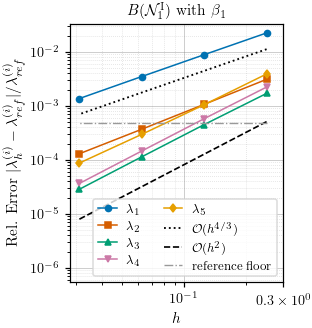

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


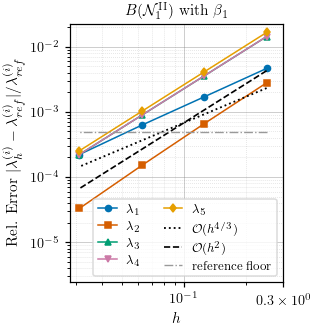

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


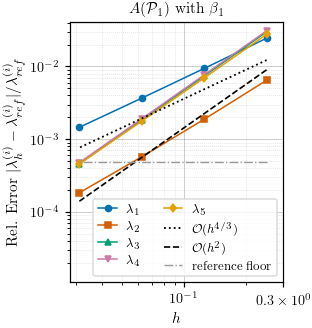

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


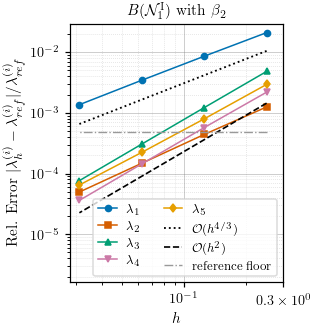

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


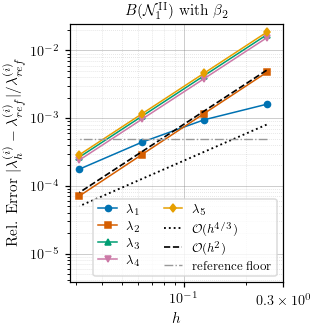

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


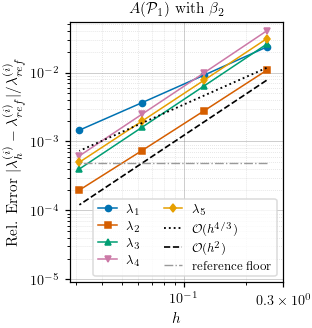

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


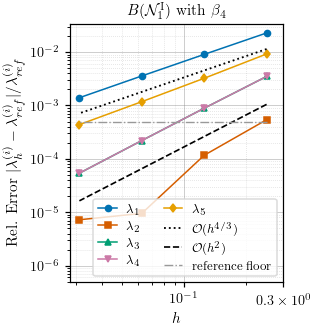

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


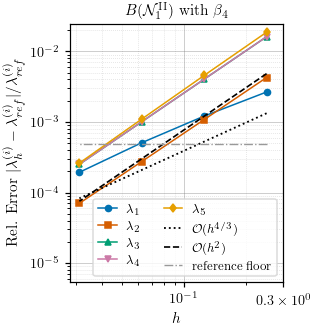

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


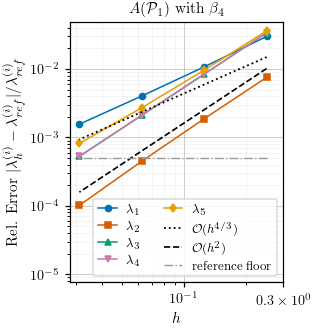

In [23]:
# h-refinement under advection: one panel per field and formulation.  The grey
# line is the cross-validation floor -- below it the panel measures the reference.
for k in ADVECTED:
    relative_spreads = REF[k]["spread"][:N_EIGS] / np.abs(REF[k]["adopted"][:N_EIGS])
    floor = relative_spreads.max()
    for f in FORMS:
        df = h_adv[(f, k)]
        h = df["h"].to_numpy()
        e0, e2 = df[EIG_COLS[0]].to_numpy(), df[EIG_COLS[2]].to_numpy()
        conv_panel(
            h, [(rf"$\lambda_{{{j+1}}}$", df[EIG_COLS[j]].to_numpy())
                for j in range(N_EIGS)],
            refs=[(h, 0.5 * e0[0] * (h / h[0]) ** CORNER_L["h_rate"],
                   dict(ls=":", lw=1.2, label=r"$\mathcal{O}(h^{4/3})$")),
                  (h, 0.3 * e2[0] * (h / h[0]) ** 2,
                   dict(ls="--", lw=1.1, label=r"$\mathcal{O}(h^{2})$")),
                  (h, np.full_like(h, floor),
                   dict(ls="-.", lw=0.9, color="0.6", label="reference floor"))],
            xlabel=r"$h$", ylabel=REL_ERR,
            title=rf"{TEX1[f]} with {FIELDS[k].tex}",
            xticks=[0.1, 0.3],
            xticklabels=[r"$10^{-1}$", r"$0.3 \times 10^{0}$"],
            name=f"domreg_h_{k}_{TAG[f]}")

## Figure 4.14: L-shape ε-pseudospectra for β4 and β7


$\varepsilon$-pseudospectra of $A(\mathcal{P}_2)$, $B(\mathcal{N}^{\mathrm{I}}_2)$, $B(\mathcal{N}^{\mathrm{II}}_2)$ for $\beta_4$ (top row) and $\beta_7$ (bottom row) on the uniform $N=32$ mesh: $R_m=10$, $p=2$, $\tau=0.9$, 100 eigenvalues, window $[0,14]\times[-4,4]$, one colour scale. Output `pseudosptrab4b7.eps`.


In [24]:
PS_N, PS_R, PS_NEV = 32, 2, 100
PS_RM = 10
PS_WINDOW = ((0.0, 14.0), (-4.0, 4.0))
PS_FORMS = ["A(P)", "B(N1)", "B(N2)"]          # the two columns of every grid below
PS_FIELDS = ["b4", "b7"]              # W^{1,inf}, then L^inf \ W^{1,inf}
mesh_ps = lshape_mesh(PS_N)


def metric_for(form, mesh, r=PS_R):
    r"""The Gram matrix of the norm a perturbation is measured in.

    `None` asks the module for the pencil's own M, which for the two B rows is
    already the $L^2$ metric on the field.  A(P) gets the stiffness matrix, so
    that what is measured is $|A|_{H^1} = \|\nabla\times A\|_{L^2} = \|B\|_{L^2}$
    and its levels line up with the mixed rows rather than sitting decades below
    them.  The rank-one gauge border needs no padding: a metric that is a leading
    block of the pencil is accepted.
    """
    if form != "A(P)":
        return None
    V = space(form, mesh, r)
    a_, z = TrialFunction(V), TestFunction(V)
    return assemble(inner(grad(a_), grad(z)) * dx).petscmat


def run_ps(form, mesh, beta, tau, Rm=1.0, r=PS_R, window=PS_WINDOW, nev=PS_NEV,
           **meta):
    """Assemble one pencil and hand it to the pseudospectrum engine."""
    A, M, W = build_pencil(form, mesh, r, beta=beta, eps=Constant(1.0 / Rm))
    out = ps.pseudospectrum(A, M, tau, nev=nev, window=window,
                            metric=metric_for(form, mesh, r),
                            form=form, Rm=Rm, label=form, **meta)
    out["kappa1"] = condition_estimates(A, M, tau)[r"Hager $\kappa_1$"]
    return out


def ps_grid(panels, titles, name, *, share="all", row_height=0.38):
    r"""A grid of pseudospectrum panels across the text width.

    `panels` is a list of rows, each row a list of results, and `titles` matches
    it.  `share="all"` puts one colour scale on the whole grid, which
    `ps.shared_scale` only permits when every panel is drawn on the same window;
    `share="row"` gives each row its own.  The colour bar sits at the end of each
    row either way, and the panels are lettered (a), (b), ... row by row.
    """
    nrow, ncol = len(panels), len(panels[0])
    scales = ([ps.shared_scale([r for row in panels for r in row])] * nrow
              if share == "all" else [ps.shared_scale(row) for row in panels])
    with matplotlib.rc_context(PS_RC):
        fig, axes = plt.subplots(
            nrow, ncol, figsize=(fig_width, fig_width * row_height * nrow),
            sharex=(True if share == "all" else "col"),
            sharey=(True if share == "all" else "row"), squeeze=False)
        k = 0
        for i, row in enumerate(panels):
            lo, hi = scales[i]
            for j, res in enumerate(row):
                ax = axes[i][j]
                ps.plot_pseudospectrum(
                    res, ax=ax, cmap="magma", title=titles[i][j],
                    vmin=lo, vmax=hi, per_decade=2, grid=True,
                    legend=(i == 0 and j == 0), colorbar=(j == ncol - 1),
                    colorbar_label=r"$\sigma_{\min}(z - L)$",
                    colorbar_kw={"pad": 0.02, "fraction": 0.045},
                    legend_kw={"frameon": True, "facecolor": "lightgray",
                               "edgecolor": "black", "loc": "lower left",
                               "fontsize": base_fontsize - 2},
                    eig_kw={"color": "white", "markersize": 3})
                ax.text(-0.05, 1.05, f"({chr(97 + k)})", transform=ax.transAxes,
                        fontsize=base_fontsize, fontweight="bold", va="bottom")
                k += 1
                if j:
                    ax.set_ylabel("")
                if i < nrow - 1:
                    ax.set_xlabel("")
        if axes[0][0].get_legend():
            for text in axes[0][0].get_legend().get_texts():
                text.set_text(r"$\lambda_i$")
        plt.tight_layout(pad=0.2)
        save_fig(fig, name)
        plt.show()

In [25]:
# Four solves: two fields on the two formulations, one mesh, one window.
ps_L = {(f, k): run_ps(f, mesh_ps, FIELDS[k](mesh_ps), 0.9, Rm=10,
                       wind=k)
        for k in PS_FIELDS for f in PS_FORMS}

# One epsilon for the whole grid, so a bulge is a like-for-like number.
eps_L = float(np.percentile(
    np.concatenate([r["sigma"] for r in ps_L.values()]), 2.0))
rows = {}
for k in PS_FIELDS:
    for f in PS_FORMS:
        res = ps_L[(f, k)]
        b, e = ps.bulge(res, eps=eps_L)
        rows[(FIELDS[k].tex, f)] = {
            "regularity": FIELDS[k].regularity, r"$\varepsilon$": e, "bulge": b,
            "eigs in window": res["n_in"],
            r"max $|\mathrm{Im}\,\lambda|$":
                float(np.abs(res["ritz_in"].imag).max()),
            "win err": res["win_err"], r"$\kappa_1$": res["kappa1"]}
frame = pd.DataFrame(rows).T
frame.index = pd.MultiIndex.from_tuples(frame.index, names=["beta", "form"])
show(frame, default="{:.3e}", rules=[("eigs", "{:.0f}"), ("bulge", "{:.4f}"),
                                     ("regularity", "{}")],
     caption=rf"Pseudospectra on $\Omega_L$ at $N = {mesh_ps.num_cells()}$ cells, "
             rf"$r = {PS_R}$, $R_m = {PS_RM:g}$, nev $= {PS_NEV}$. The bulge is how "
             rf"far the $\varepsilon$-pseudospectrum reaches beyond an "
             rf"$\varepsilon$-disc about the spectrum -- zero for an operator "
             rf"normal in the metric. Both fields are gradients, so "
             rf"$|\mathrm{{Im}}\,\lambda|$ should be round-off in every row.")

**Pseudospectra on $\Omega_L$ at $N = 12288$ cells, $r = 2$, $R_m = 10$, nev $= 100$. The bulge is how far the $\varepsilon$-pseudospectrum reaches beyond an $\varepsilon$-disc about the spectrum -- zero for an operator normal in the metric. Both fields are gradients, so $|\mathrm{Im}\,\lambda|$ should be round-off in every row.**

regularity  \
beta                                   form                                      
$\beta_4$                              A(P)                     $W^{1,\infty}$   
                                       B(N1)                    $W^{1,\infty}$   
                                       B(N2)                    $W^{1,\infty}$   
$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$ A(P)   $L^\infty\setminus W^{1,\infty}$   
                                       B(N1)  $L^\infty\setminus W^{1,\infty}$   
                                       B(N2)  $L^\infty\setminus W^{1,\infty}$   

                                             $\varepsilon$   bulge  \
beta                                   form                          
$\beta_4$                              A(P)      2.780e-04  0.1385   
                                       B(N1)     2.780e-04  0.1369   
                                       B(N2)     2.780e-04  0.1374   
$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$ A(P)      2.780e-04  0.4267   
                                       B(N1)     2.780e-04  0.4286   
                                       B(N2)     2.780e-04  0.4280   

                                             eigs in window  \
beta                                   form                   
$\beta_4$                              A(P)              32   
                                       B(N1)             32   
                                       B(N2)             32   
$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$ A(P)              33   
                                       B(N1)             33   
                                       B(N2)             33   

                                             max $|\mathrm{Im}\,\lambda|$  \
beta                                   form                                 
$\beta_4$                              A(P)                     3.589e+00   
                                       B(N1)                    3.588e+00   
                                       B(N2)                    3.589e+00   
$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$ A(P)                     2.435e+00   
                                       B(N1)                    2.429e+00   
                                       B(N2)                    2.431e+00   

                                                win err $\kappa_1$  
beta                                   form                         
$\beta_4$                              A(P)   2.894e-10  1.164e+07  
                                       B(N1)  8.955e-12  6.514e+07  
                                       B(N2)  3.432e-11  8.434e+07  
$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$ A(P)   2.242e-11  5.601e+06  
                                       B(N1)  8.275e-10  5.371e+07  
                                       B(N2)  4.078e-10  7.259e+07

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


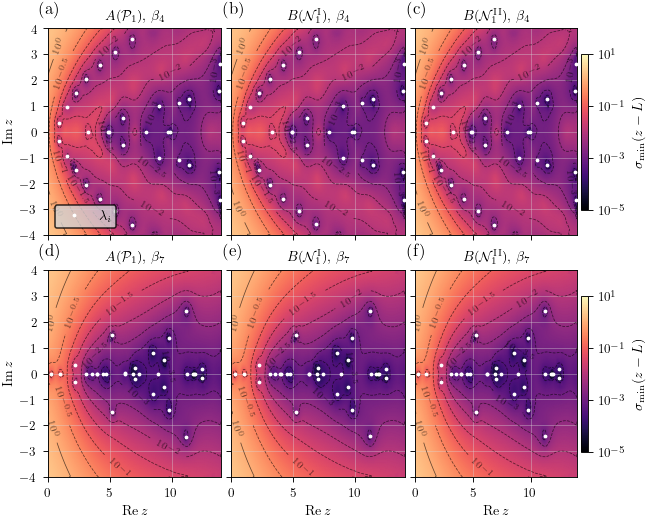

In [26]:
# The 2x2: rows are the two sides of the W^{1,inf} hypothesis, columns the two
# formulations.  One window and one colour scale for all four, so a difference
# between panels is a difference in the resolvent and not in the axes.
ps_grid([[ps_L[(f, k)] for f in PS_FORMS] for k in PS_FIELDS],
        [[rf"{TEX1[f]}, $\beta_4$" for f in PS_FORMS],
         [rf"{TEX1[f]}, $\beta_7$"
          for f in PS_FORMS]],
        "pseudosptrab4b7", share="all", row_height=0.40)

# Appendix


## Table A.12: L-shape formulation comparison for β1, β2, β4


Produced by the cells under Figure 4.13 above (source cells 26-27): the cross-validation reference at $N=32$, $p=2$, $\gamma=1$, $R_m=1$, $\tau=0.9$, 100 eigenvalues, and its top-five + $\kappa_1$ slice.


## Figure A.10: L-shape h-refinement across formulations for β1, β2, β4


Produced by the cells under Figure 4.13 above: all nine panels `domreg_h_{b1,b2,b4}_{AP,BN1,BN2}.eps`.


## Notes

**Parameter re-runs.** Figure 4.12(a), source cell 21: `gamma=1` changed to `gamma=0.5` in
`mesh_panel(lshape_mesh(8, gamma=...), "domreg_graded_mesh_g05", lw=0.3)`. The saved cell drew the uniform mesh
under the graded-mesh file name (that uniform rendering, dated 1 September, is what the working folder holds); the
copy in this folder's `figures/` is the one the thesis was compiled from and shows the graded mesh the caption
describes ($\gamma=0.5$, $N=8$), so the re-run follows the caption and the file name. Stored output dropped.

**Caveats (reported, not fixed).**
- Table 4.6: the solve uses `r=2` (as in the thesis) but the caption string prints `r = 1`. The cell prints MUMPS
  `COND1` = 3.1e+05, 2.4e+05, 1.9e+02 (B(N1), B(N2), A(P)) via `get_mumps_cond1`; the thesis row
  $\kappa_1(A-\tau M)$ = 4.8e4, 4.7e4, 7.5e1 is the $r=1$, $N=32$ MUMPS `COND1` of the $\beta=0$ $h$-study, printed in
  the $n=32$ row of the tables under Figure 4.10 (source cell 12); the thesis table thus pairs $r=2$ eigenvalues with
  $r=1$ condition numbers. Eigenvalues agree to all printed digits. `solve_form`
  runs with its default `nev=30`; the caption says 40 eigenvalues.
- Figure 4.10: the $h$-study is run with `n_eigs=10` (`nev=70`); the $p$-study with `nev=40`. The thesis caption says
  40 eigenvalues for both.
- Figure 4.11: the code writes mode index 0 ($\lambda_1$, the corner mode) to `domreg_mode_corner` and index 3 to
  `domreg_mode_smooth`; the thesis subcaptions label `domreg_mode_smooth` as $\lambda_{1,h}$ and `domreg_mode_corner`
  as $\lambda_{4,h}$. The print statement labels `values[1]` as `lambda_4`.
- Figure 4.12(b): the panel cell (source 23) has no stored output (never executed in the saved session); the
  figure file exists in `figures/`.
- Table A.12 / Figure 4.13: `REF_GAMMA = 1` (uniform, as the thesis table caption states) but both caption strings
  print $\gamma = 1/2$, and the thesis body text says "graded criss-cross mesh ($\gamma=1/2$)". The stored numbers
  match the thesis table exactly. The Table A.12 slice (source cell 27) is placed directly after its producing
  cell (source 26) under Figure 4.13 rather than under the appendix heading, because the pseudospectra summary
  (source cell 32, Figure 4.14) rebinds `frame`; the appendix heading points back to it.
- Figure 4.14: `FIELDS["b7"]` is labelled $(\mathrm{sign}(y-\pi/2),0)$ but `_b7` switches sign at $y=0$ (and calls
  `Constant(0,0)`); the summary-table caption says both fields are gradients, though $\beta_4$ is a rotation (max
  $|\mathrm{Im}\,\lambda|\approx 3.6$ in the table).
- Execution counts in the source are not monotone (e.g. cell 16 ran before cells 14-15, cells 6/16 and 12/13 share a
  count): the saved outputs come from more than one kernel session.

**Dropped cells (source indices).**
- 0, 4, 7, 19, 24, 30: original markdown, replaced by the headings above.
- 8: DoF table of the $r=1$ mesh sequence; not a thesis item.
- 9: mesh-sequence panels `domreg_lshape_mesh_n{4,8,16}`; not a thesis item, nothing depends on them.
- 34: empty cell.
